Install scikit-learn module

`pip install scikit-learn`

Scikit-learn already has the logic for machine learning algorithms built in. Instead of writing separate functions for cost, gradient, gradient descent, prediction, and evaluation, you can use its ready-made modules. This saves time, reduces errors, and lets you focus on building and improving your machine learning model instead of writing the algorithm from scratch.

In [92]:
import numpy as np

X_train = np.array([
    [952,  2, 1, 65],
    [1244, 3, 2, 64],
    [1947, 3, 2, 17],
])
y_train = np.array([271.5, 300.0, 509.8])

# Features - Size, Bedrooms, Floors, Age - Building details
# Output - Price

Normalization using `StandardScaler` for z-score

In [93]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_norm = scaler.fit_transform(X_train)

`scaler = StandardScaler()` creates the tool — think of it like creating an empty calculator that hasn't looked at your data yet.'

`scaler.fit_transform(X_train)` does two jobs in one call:

**fit** — looks at X_train and calculates the mean and standard deviation of each column

**transform** — applies the z-score formula (x - mean) / std to every value, using those calculated numbers

In [94]:
print("Original:\n", X_train)
print("Normalized:\n", X_norm)

Original:
 [[ 952    2    1   65]
 [1244    3    2   64]
 [1947    3    2   17]]
Normalized:
 [[-1.03 -1.41 -1.41  0.73]
 [-0.33  0.71  0.71  0.68]
 [ 1.36  0.71  0.71 -1.41]]


After normalization, now we need to do linear regression using Gradient Descent

In [95]:
from sklearn.linear_model import SGDRegressor

sgdr = SGDRegressor(max_iter=10000)
sgdr.fit(X_norm,y_train)

,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",10000
,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide <sgd_mathematical_formulation>`.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None


`sgdr = SGDRegressor(max_iter=1000)` — creates the model, untrained and maximum iterations are 1000 as mentioned, it will tell if iterations aren't enough for convergence

`sgdr.fit(X_norm, y_train)` — runs gradient descent internally on the scaled data, updates w and b until it converges (or hits maximum iterations)

---

what if we want to choose custom learning rate?

```python
sgdr = SGDRegressor(max_iter=1000, learning_rate='constant', eta0=0.01)
```

`eta0` — this is your learning rate (α) — same value you pick by hand in your own gradient descent loop. Default is 0.01.
`learning_rate` — controls whether that rate stays fixed or changes over training:

    `'constant'` — uses eta0 for every iteration, unchanged (closest to what you do manually)
    `'invscaling'` (sklearn's default) — starts at eta0 and shrinks it gradually as training progresses
    `'adaptive'` — keeps it constant unless the loss stops improving, then shrinks it

In [96]:
print(sgdr)

SGDRegressor(max_iter=10000)


lets print no.of iterations it took and w and b values as well

In [97]:
print(f"Slope/Coef (w) values are {sgdr.coef_}")
print(f"Intercept (b) values is {sgdr.intercept_}")


Slope/Coef (w) values are [ 48.31  -1.74  -1.74 -60.9 ]
Intercept (b) values is [360.]


So our equation is 

`price ≈ 48.31×size_scaled − 1.75×bedrooms_scaled − 1.75×floors_scaled − 60.91×age_scaled + 360`

scaled means ->normalized data

lets predict

In [98]:
y_pred_sgdr = sgdr.predict(X_norm)

print("Predicted:", y_pred_sgdr)
print("Actual: ", y_train)

Predicted: [270.89 299.99 509.12]
Actual:  [271.5 300.  509.8]


In [99]:
w_norm = sgdr.coef_
b_norm = sgdr.intercept_

y_pred = np.dot(X_norm,w_norm)+b_norm

In [100]:
print("Match:", np.allclose(y_pred, y_pred_sgdr))

Match: True


`np.allclose` checks whether two arrays are equal within a small tolerance, instead of exactly equal.

`sgdr.predict(X_norm)` and `np.dot(X_norm, w_norm) + b_norm` are computing the identical formula, just one way is automatic and one is manual.

Lets plot the graph

scikit-learn aka `sklearn` library in python.

`sklearn.linear_model`, here `linear_model` holds regression related tools

`from sklearn.linear_model import SDGRegressor` which is linear regression model using gradient descent (SGD=Stochastic Gradient Descent)

---


`sklearn.preprocessing`, here `preprocessing` is module for preparing/cleaning data before training

`from sklearn.preprocessing import StandardScaler`, is the tool that does z-score normalization

`from sklearn.preprocessing import PolynomialFeatures` for polynomials

---

`np.set_printoptions(precision=2)`

This one has nothing to do with ML. It's just a display setting for NumPy — it tells NumPy "when you print any array, round numbers to 2 decimal places." Purely cosmetic, so output isn't cluttered with long decimals like 271.49999982. This is just info

---

Now lets start!!


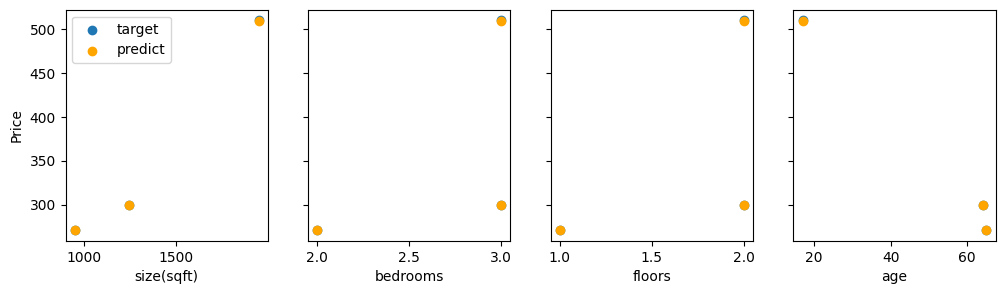

In [101]:
import matplotlib.pyplot as plt 

X_features = ['size(sqft)', 'bedrooms', 'floors', 'age']

fig, ax = plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:, i], y_train, label='target')
    ax[i].scatter(X_train[:, i], y_pred, color='orange', label='predict')
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price")
ax[0].legend()
plt.show()

### Polynomial!!!!!!!!!!!!!

In [102]:
import seaborn as sns
df = sns.load_dataset("anscombe")
data= df[df["dataset"] == "II"]  # this subset is a perfect quadratic curve
x = data['x'].to_numpy()
y = data['y'].to_numpy()

sort_idx = np.argsort(x)

x = x[sort_idx]
y = y[sort_idx]

X = x.reshape(-1,1) 
# for x.shape it will (11,) which is 1D array here [1,2,3,4]
# we need to reshape input only as input is rows (samples) and columns (features) - reshape 
# [[1],
#  [2],
#  [3],
#  [4]
# ]


In [103]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)


**PolynomialFeatures**  creates the tool — same pattern as StandardScaler and SGDRegressor before it: create the object, then fit_transform.

`degree=2` means: for each row, generate *x* and $x^2$ as separate columns -  Feature Engineering

`include_bias=False` — by default, sklearn adds an extra column of all 1s (for the bias/intercept term). You set this to False because SGDRegressor already adds its own intercept — you don't want two.

`fit` — looks at your input X and figures out what transformation to set up

`transform` — actually applies that transformation to the data: takes each row's x value and produces [x, x²].

In [104]:
X_poly_scaled.shape

(11, 2)

In [105]:
sgdr_poly = SGDRegressor(max_iter=1000 )
sgdr_poly.fit(X_poly_scaled ,y)

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide <sgd_mathematical_formulation>`.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None


In [106]:
print(f"Slope/Coef (w) values are {sgdr_poly.coef_}")
print(f"Intercept (b) values is {sgdr_poly.intercept_}")

Slope/Coef (w) values are [1.09 0.41]
Intercept (b) values is [7.31]


In [107]:
y_pred_poly = sgdr_poly.predict(X_poly_scaled)

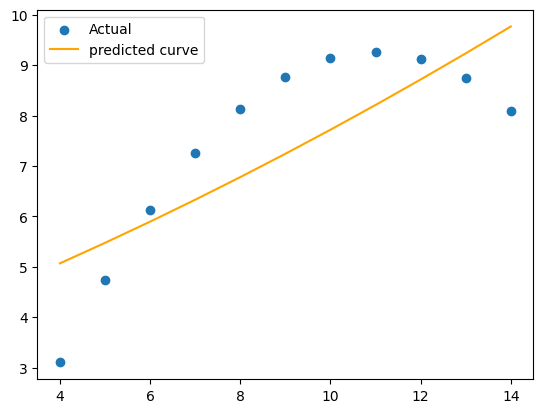

In [108]:
plt.scatter(x,y,label='Actual')
plt.plot(x, y_pred_poly, color='orange', label='predicted curve')
plt.legend()
plt.show()


#### Our Graph is not looking accurate lets change paramters of SGDRegressor

In [144]:
sgdr_poly_new_example = SGDRegressor(max_iter=10000,verbose=1)
sgdr_poly_new_example.fit(X_poly_scaled,y)

-- Epoch 1
Norm: 0.23, NNZs: 2, Bias: 0.560076, T: 11, Avg. loss: 28.092139, Objective: 28.092144
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 0.31, NNZs: 2, Bias: 0.929361, T: 22, Avg. loss: 24.473811, Objective: 24.473813
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 0.38, NNZs: 2, Bias: 1.239529, T: 33, Avg. loss: 22.078479, Objective: 22.078485
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 0.44, NNZs: 2, Bias: 1.510515, T: 44, Avg. loss: 20.136793, Objective: 20.136801
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 0.48, NNZs: 2, Bias: 1.754361, T: 55, Avg. loss: 18.499062, Objective: 18.499071
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 0.53, NNZs: 2, Bias: 1.977990, T: 66, Avg. loss: 17.081715, Objective: 17.081730
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 0.57, NNZs: 2, Bias: 2.183223, T: 77, Avg. loss: 15.834584, Objective: 15.834596
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 0.60, NNZs: 2, Bias: 2.374341, T: 88, Avg. loss: 14.

,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",10000
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",1
,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide <sgd_mathematical_formulation>`.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None


if you observe in `sgdr_poly_new_example` last 5 iterations where was no change I mean similar thats why it convereged, see below where its paramater mentioned as `n_iter_no_change`

`verbose` is log, defualt is 0

`eta0` — starting learning rate (step size), same as  alpha=0.1

`alpha` — regularization strength (penalizes large weights); 0 = off, matches your code

alpha=0 means no penalty — the model only cares about fitting the data, exactly like own compute_cost function. Higher alpha forces smaller weights even if that means a slightly worse fit — used to prevent overfitting on real datasets.

`tol` — how small improvement must get before stopping early; tiny value = don't stop early

`n_iter_no_change` = how many epochs (iterations) in a row have to show no improvement before sklearn decides "this has converged, stop training."

Example: n_iter_no_change=5 (default) means — check the last 5 epochs. If none of them improved the loss, stop. 

n_iter_no_change=50 means — check the last 50 epochs instead. Only stop if all 50 show no improvement

In [143]:
sgdr_poly_new = SGDRegressor(max_iter=10000,eta0=0.1,learning_rate='constant',alpha=0,tol=1e-6,n_iter_no_change=50,verbose=1 )
sgdr_poly_new.fit(X_poly_scaled,y)

-- Epoch 1
Norm: 1.82, NNZs: 2, Bias: 5.004125, T: 11, Avg. loss: 14.273950, Objective: 14.273950
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 0.88, NNZs: 2, Bias: 6.754280, T: 22, Avg. loss: 2.392806, Objective: 2.392806
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 0.97, NNZs: 2, Bias: 7.482623, T: 33, Avg. loss: 0.966774, Objective: 0.966774
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 0.96, NNZs: 2, Bias: 7.254629, T: 44, Avg. loss: 0.970457, Objective: 0.970457
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 1.20, NNZs: 2, Bias: 7.496172, T: 55, Avg. loss: 0.942067, Objective: 0.942067
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 1.09, NNZs: 2, Bias: 7.525258, T: 66, Avg. loss: 0.742213, Objective: 0.742213
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 1.45, NNZs: 2, Bias: 7.410059, T: 77, Avg. loss: 1.033196, Objective: 1.033196
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 1.42, NNZs: 2, Bias: 7.415318, T: 88, Avg. loss: 0.808999, Objec

,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",10000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",1e-06
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",1
,"learning_rate learning_rate: str, default='invscaling'The learning rate schedule:- 'constant': `eta = eta0`- 'optimal': `eta = 1.0 / (alpha * (t + t0))` where t0 is chosen by a heuristic proposed by Leon Bottou.- 'invscaling': `eta = eta0 / pow(t, power_t)`- 'adaptive': eta = eta0, as long as the training keeps decreasing. Each time n_iter_no_change consecutive epochs fail to decrease the training loss by tol or fail to increase validation score by tol if early_stopping is True, the current learning rate is divided by 5.- 'pa1': passive-aggressive algorithm 1, see [1]_. Only with `loss='epsilon_insensitive'`. Update is `w += eta y x` with `eta = min(eta0, loss/||x||**2)`.- 'pa2': passive-aggressive algorithm 2, see [1]_. Only with `loss='epsilon_insensitive'`. Update is `w += eta y x` with `eta = hinge_loss / (||x||**2 + 1/(2 eta0))`... versionadded:: 0.20 Added 'adaptive' option... versionadded:: 1.8 Added options 'pa1' and 'pa2'",'constant'
,"eta0 eta0: float, default=0.01The initial learning rate for the 'constant', 'invscaling' or'adaptive' schedules. The default value is 0.01.Values must be in the range `(0.0, inf)`.For PA-1 (`learning_rate=pa1`) and PA-II (`pa2`), it specifies theaggressiveness parameter for the passive-aggressive algorithm, see [1] where itis called C:- For PA-I it is the maximum step size.- For PA-II it regularizes the step size (the smaller `eta0` the more it regularizes).As a general rule-of-thumb for PA, `eta0` should be small when the data isnoisy.",0.1
,"n_iter_no_change n_iter_no_change: int, default=5Number of iterations with no improvement to wait before stoppingfitting.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Integer values must be in the range `[1, max_iter)`... versionadded:: 0.20 Added 'n_iter_no_change' option",50
,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide <sgd_mathematical_formulation>`.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"

In [140]:
y_pred = sgdr_poly_new.predict(X_poly_scaled)

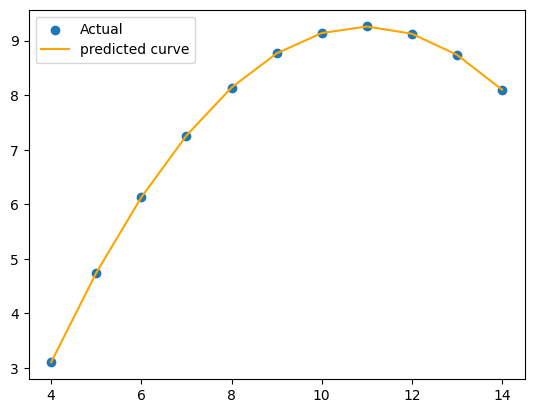

In [141]:
plt.scatter(x,y,label='Actual')
plt.plot(x, y_pred, color='orange', label='predicted curve')
plt.legend()
plt.show()